# Trapped-ion quantum motion: wavepacket averaging, the Coulomb crystal, and motional time dilation

For a ground-state-cooled ion, this engine does not walk a classical mm-scale
trajectory through a field map: it evaluates shift expectations over the
atom's quantum motional state, a Gaussian wavepacket of nanometer width
sitting at a fixed equilibrium position the field map itself supplies. That
is the picture NIST Ion Storage's trapped-ion clocks live in, and this
notebook walks the three trapped-ion capabilities this project ships against
exactly that picture: wavepacket-averaged field evaluation at a single trap
site (Section 1), the two-ion Coulomb-crystal quadrupole case (Section 2,
recapping notebook 08), and the motional time-dilation budget line
reproduced against a published Al+ evaluation (Section 3, the centerpiece),
closing with the excess-micromotion input channel (Section 4) and a scope
statement (Section 5).

**Status: pre-beta research code.**

In [1]:
%matplotlib inline
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "benchmarks"))

import loaders
import run_motional_al_ion
import run_roos_quadrupole_slope as roos

from cliffordclock import constants
from cliffordclock.ensemble.lattice import hermite_gaussian_nodes
from cliffordclock.ensemble.species import get_species
from cliffordclock.ensemble.traps import HarmonicTrap
from cliffordclock.integrator.omega import (
    MotionalMode,
    motional_pivot_perturbation,
    motional_pivot_uncertainty,
)
from cliffordclock.pipeline import _MOTIONAL_EMM_ROADMAP_NOTE, PipelineConfig, run_pipeline_full

_notebook_start_s = time.time()
np.set_printoptions(precision=6, suppress=False)
al_ion = get_species("Al27+")
print(f"species: Al27+, clock frequency nu_0 = {al_ion.clock_frequency_hz:.6f} Hz")
print(f"species: Al27+, mass = {al_ion.mass_kg:.10e} kg")

species: Al27+, clock frequency nu_0 = 1121015393207857.375000 Hz
species: Al27+, mass = 4.4803898869e-26 kg


## 1. The quantum position distribution: a wavepacket, not a point

A ground-state-cooled ion is not a classical point sitting at its
equilibrium site: its position is a Gaussian probability distribution, the
ground state of the local trap's harmonic confinement, with a width set
entirely by the trap frequency and the ion's mass,
`sigma_x = sqrt(hbar / (2 m omega))`. `ensemble.regime: lattice` builds
exactly this distribution as Gauss-Hermite quadrature nodes and weights
against the harmonic-oscillator eigenstate density
(`cliffordclock.ensemble.lattice.hermite_gaussian_nodes`), so a
lattice-regime evaluation sums a field-driven shift over the wavepacket's
own sampling of positions, never along a trajectory. The cell below builds
that quadrature for a single trapped Al+ ion at a representative secular
frequency and prints both the closed-form width and the quadrature's own
node positions and weights side by side, so the ~10 nm scale a ground-state
ion actually occupies comes directly from the engine's inputs, not from a
claim about them.

In [2]:
TRAP_FREQUENCY_HZ = 2.0e6  # representative Al+ secular frequency (Marshall et al. Table S2 scale)
omega_trap = 2.0 * math.pi * TRAP_FREQUENCY_HZ
trap = HarmonicTrap(omega_xyz=(omega_trap, omega_trap, omega_trap), center=(0.0, 0.0, 0.0))

sigma_x_m = math.sqrt(constants.HBAR / (2.0 * al_ion.mass_kg * omega_trap))
print(f"trap frequency: {TRAP_FREQUENCY_HZ / 1e6:.2f} MHz (angular omega = {omega_trap:.6e} rad/s)")
print(f"ground-state position width sigma_x = sqrt(hbar / (2 m omega)) = {sigma_x_m * 1e9:.3f} nm")

N_QUAD = 8
nodes, weights = hermite_gaussian_nodes(al_ion, trap, (0, 0, 0), N_QUAD)
nodes = np.array(nodes).reshape(N_QUAD, N_QUAD, N_QUAD, 3)
weights = np.array(weights).reshape(N_QUAD, N_QUAD, N_QUAD)
x_nodes_nm = nodes[:, 0, 0, 0] * 1e9
x_weights = weights.sum(axis=(1, 2))

print()
print(
    f"Gauss-Hermite quadrature, n_quad={N_QUAD}, motional_n=(0,0,0) (ground state), "
    "x-axis marginal:"
)
for x_nm, w in zip(x_nodes_nm, x_weights, strict=True):
    print(f"  x = {x_nm:+8.3f} nm   weight = {w:.6e}")
print(f"  sum of weights: {x_weights.sum():.10f}")

trap frequency: 2.00 MHz (angular omega = 1.256637e+07 rad/s)
ground-state position width sigma_x = sqrt(hbar / (2 m omega)) = 9.677 nm

Gauss-Hermite quadrature, n_quad=8, motional_n=(0,0,0) (ground state), x-axis marginal:
  x =  -40.109 nm   weight = 1.126145e-04
  x =  -27.121 nm   weight = 9.635220e-03
  x =  -15.837 nm   weight = 1.172399e-01
  x =   -5.217 nm   weight = 3.730123e-01
  x =   +5.217 nm   weight = 3.730123e-01
  x =  +15.837 nm   weight = 1.172399e-01
  x =  +27.121 nm   weight = 9.635220e-03
  x =  +40.109 nm   weight = 1.126145e-04
  sum of weights: 1.0000000000


With the wavepacket itself on the table, the question this raises directly
is whether averaging a field-driven shift over that ~10 nm spread ever
differs measurably from evaluating the field at the ion's single
equilibrium point, the fixed location a field map reports. The cell below
builds a synthetic field with genuine spatial curvature (a localized
Gaussian bump, standing in for a fringing or patch-potential feature near a
trap electrode) at a series of curvature length scales, and compares the
E14b quadratic DC-Stark shift computed two ways at each scale: the full
wavepacket-averaged expectation (`n_quad=8`) against the field evaluated
only at the ion's equilibrium point (`n_quad=1`, which the same
Gauss-Hermite construction collapses to exactly one node at the trap center
with unit weight for the ground state).

In [3]:
def lattice_config(n_quad, width_m, offset_m, amplitude_v_m=2.0e4):
    return {
        "species": "Al27+",
        "trap": {"omega_xyz": [omega_trap, omega_trap, omega_trap], "center": [0.0, 0.0, 0.0]},
        "field": {
            "synthetic": {
                "kind": "gaussian_bump",
                "params": {
                    "amplitude": [amplitude_v_m, 0.0, 0.0],
                    "center": [offset_m, 0.0, 0.0],
                    "width": width_m,
                },
            }
        },
        "coupling": {"type": "stark_dc"},
        "ensemble": {
            "regime": "lattice",
            "temperature_uK": 1.0,
            "motional_n": [0, 0, 0],
            "n_quad": n_quad,
        },
        "integration": {"mode": "fast_path", "time_s": 1.0},
        "output": {"directory": "."},
    }


def shift_at_width(n_quad, width_m):
    offset_m = 0.7 * width_m  # ion sits on the field's slope, not its symmetric peak
    result = run_pipeline_full(PipelineConfig.from_dict(lattice_config(n_quad, width_m, offset_m)))
    return result.report.mean_fractional_shift


WIDTHS_NM = np.array([20.0, 50.0, 100.0, 300.0, 1.0e3, 1.0e4, 1.0e5, 1.0e6])
wavepacket_shifts = np.array([shift_at_width(8, w * 1e-9) for w in WIDTHS_NM])
point_shifts = np.array([shift_at_width(1, w * 1e-9) for w in WIDTHS_NM])
diffs = wavepacket_shifts - point_shifts

print(f"{'width (nm)':>12s} {'wavepacket avg':>18s} {'point eval':>18s} {'difference':>14s}")
for w, a, b, d in zip(WIDTHS_NM, wavepacket_shifts, point_shifts, diffs, strict=True):
    print(f"{w:12.0f} {a:18.6e} {b:18.6e} {d:14.3e}")

# Linear interpolation in log-log space for the width at which |difference|
# crosses 1e-18, the modern lattice-clock total-systematic-budget scale
# notebook 12 also uses.
abs_diffs = np.abs(diffs)
threshold = 1e-18
crossing_nm = None
for i in range(len(WIDTHS_NM) - 1):
    if abs_diffs[i] >= threshold >= abs_diffs[i + 1]:
        log_w0, log_w1 = np.log10(WIDTHS_NM[i]), np.log10(WIDTHS_NM[i + 1])
        log_d0, log_d1 = np.log10(abs_diffs[i]), np.log10(abs_diffs[i + 1])
        frac = (np.log10(threshold) - log_d0) / (log_d1 - log_d0)
        crossing_nm = 10.0 ** (log_w0 + frac * (log_w1 - log_w0))
        break

print()
if crossing_nm is not None:
    print(
        f"wavepacket-vs-point difference crosses {threshold:.0e} at a curvature length "
        f"scale of {crossing_nm:.0f} nm (ground-state width sigma_x = {sigma_x_m * 1e9:.1f} nm)"
    )

  width (nm)     wavepacket avg         point eval     difference
          20      -7.434894e-16      -1.131393e-15      3.879e-16
          50      -1.050462e-15      -1.131393e-15      8.093e-17
         100      -1.110292e-15      -1.131393e-15      2.110e-17
         300      -1.129018e-15      -1.131393e-15      2.374e-18
        1000      -1.131179e-15      -1.131393e-15      2.140e-19
       10000      -1.131391e-15      -1.131393e-15      2.140e-21
      100000      -1.131393e-15      -1.131393e-15      2.140e-23
     1000000      -1.131393e-15      -1.131393e-15      2.140e-25

wavepacket-vs-point difference crosses 1e-18 at a curvature length scale of 462 nm (ground-state width sigma_x = 9.7 nm)


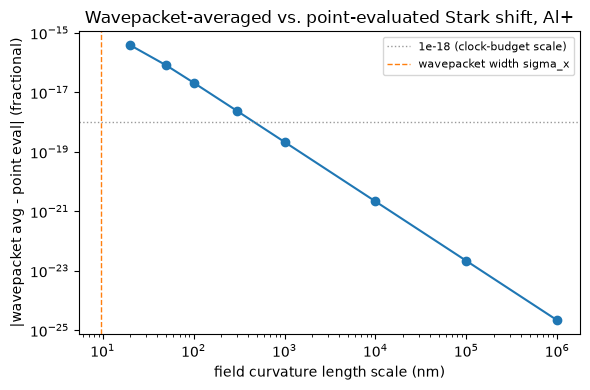

In [4]:
fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.plot(WIDTHS_NM, abs_diffs, "o-", color="C0")
ax.axhline(
    threshold,
    color="0.6",
    linestyle=":",
    linewidth=1,
    label=f"{threshold:.0e} (clock-budget scale)",
)
ax.axvline(
    sigma_x_m * 1e9, color="C1", linestyle="--", linewidth=1, label="wavepacket width sigma_x"
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("field curvature length scale (nm)")
ax.set_ylabel("|wavepacket avg - point eval| (fractional)")
ax.set_title("Wavepacket-averaged vs. point-evaluated Stark shift, Al+")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

At curvature length scales of tens of nanometers, comparable to the
wavepacket's own ~10 nm spread, the wavepacket-averaged shift and the point
evaluation diverge by a large fraction of the shift itself: the field
genuinely varies across the ion's own quantum extent, and a fixed-point
evaluation misses that variation. At the micron-to-millimeter scales a real
trap electrode's own geometry sets (the electrode-to-ion distance, not a
single lattice site's atomic structure), the difference falls many orders
of magnitude below any clock-relevant budget line, and evaluating the field
at the ion's single equilibrium position is exact for every practical
purpose. This is the intuition that clock ions sit at fixed positions in a
field map, confirmed quantitatively: a quantum-mechanical description of
the ion's position is what the engine already uses everywhere in this
section, and that description is exactly what shows a fixed-point
evaluation is safe once the field varies slowly compared to the wavepacket
it is sampled against.

## 2. Fields at fixed locations: the Coulomb crystal

Roos et al.'s two-ion Ca+:D5/2 crystal (Roos et al., Nature 443, 316 (2006),
quant-ph/0701215v1) is the Coulomb-crystal picture directly: each ion sits
at its own fixed equilibrium position, and the observable is a two-ion
entangled state's electric-quadrupole-shift slope against a mechanically
calibrated gradient, with the second ion doubling the gradient its
neighbor sees. Notebook 08 walks the full derivation cell by cell; the cell
below runs the same case object live and prints its headline numbers and
classification label verbatim, so the residual (matching the field's own
known Ca+ quadrupole-moment tension) and the class label both come from the
engine's own output. See `notebooks/08_roos_quadrupole_slope.ipynb` for the
full three-stage pipeline (angular factor, per-ion shift, two-ion
combination) this reuses.

In [5]:
roos_case = roos.run_roos_quadrupole_slope_case()
cv = roos_case.cross_vintage

print(f"case_class:      {cv.case_class!r}")
print(f"Theta (input):    {cv.theta_au} ea0^2 (Itano theory)")
print(f"predicted slope:  {cv.predicted_slope_hz_mm2_per_v:.6f} Hz*mm^2/V")
print(f"measured slope:   {cv.measured_slope_hz_mm2_per_v} Hz*mm^2/V")
print(f"residual:         {cv.residual_fractional:+.4%}")
print(f"kpi_verdict:      {cv.kpi_verdict}")
print(f"note:             {cv.verdict_note}")

case_class:      'cross_vintage_comparison'
Theta (input):    1.917 ea0^2 (Itano theory)
predicted slope:  3.115229 Hz*mm^2/V
measured slope:   2.975 Hz*mm^2/V
residual:         +4.7136%
kpi_verdict:      NOT MET
note:             NOT MET is the EXPECTED outcome for this variant: the residual recovers the literature-known ~4.7% Theta theory-vs-measurement tension (Itano theory 1.917 ea0^2 vs Roos's measured 1.83(1) ea0^2), validating the engine's factor chain while isolating the coefficient. It is not an engine defect. See the case write-up in benchmarks/RESULTS.md and the module docstring.


## 3. The motional time-dilation row

E38 (`docs/CONVENTIONS.md` section 16) is the quantum-motional
second-order-Doppler term: for `N` normal modes each with an ordinary
secular frequency `f_i` and a mean vibrational occupation `n_bar_i`, both
exactly what resolved-sideband thermometry measures,

    omega_i = 2 * pi * f_i
    <v^2> = sum_i (hbar * omega_i / m) * (n_bar_i + 1/2)
    (P-1)_motional = -<v^2> / (2 * c^2)

with the `+1/2` zero-point term visible in the sum: even a mode cooled
exactly to `n_bar_i = 0` still contributes its irreducible
quantum-mechanical floor, the same zero-point motion behind the ~10 nm
wavepacket width in Section 1. The cell below runs
`benchmarks/run_motional_al_ion.py`'s case object live against Marshall et
al.'s (arXiv:2504.13071) own six measured normal modes for the two-ion
25Mg+-27Al+ crystal, printing each mode's frequency and `n_bar` from their
Table S2, the resulting `<v^2>`, the computed shift with its propagated
uncertainty, and the paper's own published secular-motion budget row.

In [6]:
al_case = run_motional_al_ion.run_motional_al_ion_arithmetic_reproduction_case()

print("Marshall et al. Table S2, six secular modes (27Al+/25Mg+ crystal):")
for name, freq_mhz, n_bar, n_bar_unc in loaders.MARSHALL_AL_ION_MODES_MHZ_NBAR:
    print(f"  {name:10s} f = {freq_mhz:5.2f} MHz   n_bar = {n_bar:.2f} +/- {n_bar_unc:.2f}")

print()
print(f"species:          {al_case.species_name}, mass = {al_ion.mass_kg:.6e} kg")
print(f"<v^2>:            {al_case.mean_squared_velocity_m2_s2:.6e} m^2/s^2")
print(
    f"predicted shift:  {al_case.predicted_shift_nominal:+.4e} +/- "
    f"{al_case.predicted_uncertainty_fractional:.2e}"
)
print(f"predicted band:   [{al_case.predicted_band_lo:+.4e}, {al_case.predicted_band_hi:+.4e}]")
print(
    f"published shift:  {al_case.published_shift_nominal:+.4e} "
    f"[{al_case.published_shift_lo:+.4e}, {al_case.published_shift_hi:+.4e}]"
)
print(f"bands_overlap:    {al_case.bands_overlap}")
print(f"kpi_verdict:      {al_case.kpi_verdict}")

Marshall et al. Table S2, six secular modes (27Al+/25Mg+ crystal):
  axial_com  f =  2.16 MHz   n_bar = 8.22 +/- 0.48
  axial_str  f =  3.75 MHz   n_bar = 4.50 +/- 0.19
  x_com      f =  4.22 MHz   n_bar = 5.68 +/- 0.49
  x_str      f =  3.48 MHz   n_bar = 6.69 +/- 0.51
  y_com      f =  5.37 MHz   n_bar = 4.31 +/- 0.14
  y_str      f =  4.75 MHz   n_bar = 4.84 +/- 0.24

species:          Al27+, mass = 4.480390e-26 kg
<v^2>:            2.068702e+00 m^2/s^2
predicted shift:  -1.1509e-17 +/- 2.71e-19
predicted band:   [-1.1780e-17, -1.1237e-17]
published shift:  -1.1460e-17 [-1.1840e-17, -1.1080e-17]
bands_overlap:    True
kpi_verdict:      MET


In [7]:
print("case_label (verbatim):")
print(al_case.case_label)
print()
print("scope caveat (verbatim, from the case's own field):")
print(al_case.geometric_factor_caveat)

case_label (verbatim):
arithmetic reproduction of a published standard-formula evaluation (arithmetic-reproduction fidelity, validates the engine's E38 implementation and unit chain, NOT an independent motional-Doppler physics prediction; Marshall et al.'s own secular-motion row is itself computed from their own measured inputs through the same standard formula)

scope caveat (verbatim, from the case's own field):
SCOPE CAVEAT (corrected per the project's G11 gate record, section A3): Marshall et al.'s six modes are TWO-ION (27Al+/25Mg+) crystal normal modes. The physically complete per-mode evaluation partitions each mode's zero-point and thermal motion between the two ions by their own normal-mode amplitudes, a quantity this project's E38 formula does not consume (one species/mass for every mode, CONVENTIONS.md section 16): a documented scope boundary, not an oversight. As a result the engine's per-mode contributions differ from Marshall's own per-mode values by up to several-fold, w

The predicted total printed above lands inside Marshall's own published
band, and `kpi_verdict` reads `MET`, but the caveat printed above states
exactly what that agreement does and does not mean. Marshall's six modes
are two-ion normal modes of a 27Al+/25Mg+ crystal, and the physically
complete per-mode treatment would partition each mode's motion between the
two different-mass ions by their own normal-mode amplitudes, a quantity
E38's single-species-mass formula does not take as input. Summed over the
complete six-mode set with the Al+ registry mass throughout, the engine's
naive per-mode terms reproduce Marshall's published total inside both
uncertainty bands even though the individual per-mode terms differ from
Marshall's own per-mode values by up to several-fold; this project's
independent review record (`plan/reviews/G11-e38-motional-time-dilation.md`)
derives a genuine orthogonality identity over the two-ion normal-mode basis
that is qualitatively consistent with why a single-mass sum over a complete mode set can
land near the correct total, and that same record states plainly that the
identity does not certify the level of agreement observed here. What this
validates is E38's formula and unit chain (the hbar, mass, `2*pi`, and
`c^2` arithmetic, wired correctly end to end) against a published six-mode
input set and a published total; what it does not validate is a per-mode
reproduction of Marshall's own two-ion motional physics, which is filed as
an open item alongside the project's RF/micromotion package.

## 4. The excess-micromotion channel

Ion traps add a second, independent contributor to `<v^2>`: excess
micromotion, the ion's forced oscillation at the trap's RF drive frequency
when a stray DC field displaces it from the RF null (Berkeland, Miller,
Bergquist, Itano, Wineland, J. Appl. Phys. 83, 5025 (1998), the canonical
treatment this project's ion-species notes already cite for the same
mechanism). E38 does not model the RF trap dynamics that produce excess
micromotion; it takes a lab's own measured EMM characterization, already
reduced to an equivalent rms velocity `v_rms_emm_m_s`, and adds its square
directly to the secular-mode `<v^2>` sum. The cell below adds one
illustrative EMM velocity to Marshall's own six secular modes from Section
3 and prints the resulting shift alongside the roadmap-boundary note the
engine's own report carries verbatim whenever this channel is active.

In [8]:
V_RMS_EMM_M_S = 0.02  # illustrative magnitude for a lab's own measured EMM characterization
V_RMS_EMM_UNCERTAINTY_M_S = 0.005

marshall_modes = tuple(
    MotionalMode(name=name, frequency_hz=freq_mhz * 1.0e6, n_bar=n_bar, n_bar_uncertainty=n_bar_unc)
    for name, freq_mhz, n_bar, n_bar_unc in loaders.MARSHALL_AL_ION_MODES_MHZ_NBAR
)

shift_secular_only = motional_pivot_perturbation(marshall_modes, al_ion)
shift_with_emm = motional_pivot_perturbation(marshall_modes, al_ion, v_rms_emm_m_s=V_RMS_EMM_M_S)
sigma_with_emm = motional_pivot_uncertainty(
    marshall_modes,
    al_ion,
    v_rms_emm_m_s=V_RMS_EMM_M_S,
    v_rms_emm_uncertainty_m_s=V_RMS_EMM_UNCERTAINTY_M_S,
)

print(f"secular modes only:          {shift_secular_only:+.4e}")
print(f"v_rms_emm = {V_RMS_EMM_M_S} m/s:  {shift_with_emm:+.4e} +/- {sigma_with_emm:.2e}")
print(f"EMM contribution alone:      {shift_with_emm - shift_secular_only:+.4e}")
print()
print("roadmap-boundary note (verbatim, cliffordclock.pipeline._MOTIONAL_EMM_ROADMAP_NOTE):")
print(_MOTIONAL_EMM_ROADMAP_NOTE)

secular modes only:          -1.1509e-17
v_rms_emm = 0.02 m/s:  -1.1511e-17 +/- 2.71e-19
EMM contribution alone:      -2.2253e-21

roadmap-boundary note (verbatim, cliffordclock.pipeline._MOTIONAL_EMM_ROADMAP_NOTE):
excess-micromotion scope (CONVENTIONS.md section 16 E38): a full RF-dynamics treatment of excess micromotion (the trap RF drive, stray-field-induced displacement from the RF null, and the resulting time-varying velocity, per Berkeland, Miller, Bergquist, Itano, Wineland, J. Appl. Phys. 83, 5025 (1998)) is a roadmap package, not modeled here; environment.motional_state.v_rms_emm_m_s takes the lab's own measured EMM characterization, already reduced to an equivalent rms velocity, as given.


## 5. What ships today, and what is roadmap

The trapped-ion offering today evaluates static field maps at fixed
equilibrium positions with wavepacket averaging over the ion's quantum
motional state (Section 1), the electric-quadrupole shift with real
inter-ion gradients in a Coulomb crystal (Section 2, notebook 08),
blackbody radiation with the multi-surface thermal-environment support
notebook 12 adds (E37), and motional time dilation computed from exactly
the inputs sideband thermometry supplies (Section 3, E38). RF trap
dynamics and the micromotion they drive, a full two-mass normal-mode
treatment of E38's per-mode weighting, and time-fluctuating fields more
generally remain roadmap items (`docs/roadmap.md`; `docs/CONVENTIONS.md`
sections 14 and 16), tracked openly as open work, not modeled
provisionally.

One frontier is worth naming directly, since it sits closest to this
notebook's subject. Recent proper-time work on quantum-motional effects in
trapped ions goes beyond what a classical-worldline engine can compute by
construction: this engine's contribution to that frontier is the
deterministically computed classical baseline those effects sit on top of,
not a competing treatment of the same physics.

In [9]:
print(f"notebook runtime: {time.time() - _notebook_start_s:.1f} s")

notebook runtime: 1.1 s
